<a href="https://colab.research.google.com/github/Thirupathi1356/CV-Final-Project-/blob/main/CV_Project1_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

✅ Model loaded successfully!


<IPython.core.display.Javascript object>


0: 384x640 3 persons, 319.6ms
Speed: 11.5ms preprocess, 319.6ms inference, 50.0ms postprocess per image at shape (1, 3, 384, 640)
🔊 Voice: Obstacle ahead, move left. person ahead, person ahead, person ahead


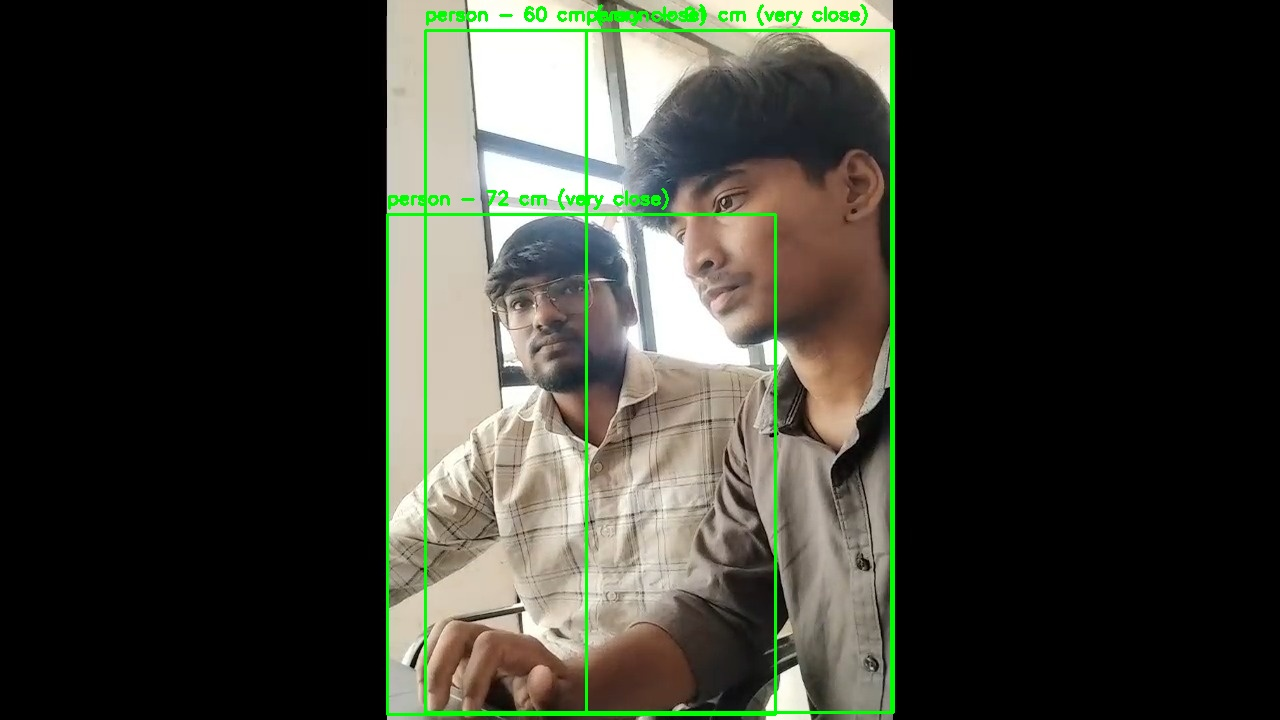

In [ ]:
# =========================
# 📦 Install Dependencies
# =========================
!pip install ultralytics --quiet
!pip install opencv-python --quiet
!pip install gTTS --quiet


# =========================
# 📚 Imports
# =========================
import cv2
import numpy as np
from ultralytics import YOLO
from gtts import gTTS
from IPython.display import Audio, display, Image
import os

from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode


# =========================
# 🤖 Load Model
# =========================
model = YOLO("yolov8n.pt")
print("✅ Model loaded successfully!")


# =========================
# 🔊 Voice Function
# =========================
def speak(text):
    print("🔊 Voice:", text)
    tts = gTTS(text=text, lang='en')
    tts.save("voice.mp3")
    display(Audio("voice.mp3", autoplay=True))


# =========================
# 📸 Capture Image (Colab Camera)
# =========================
def capture_image(delay=5):
    js = Javascript(f'''
    async function takePhoto() {{
      const div = document.createElement('div');
      const video = document.createElement('video');
      video.style.display = 'block';

      const stream = await navigator.mediaDevices.getUserMedia({{video: true}});
      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;

      await video.play();
      await new Promise(resolve => setTimeout(resolve, {delay*1000}));

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);

      stream.getTracks().forEach(track => track.stop());
      div.remove();

      return canvas.toDataURL('image/jpeg');
    }}
    ''')

    display(js)
    data = eval_js('takePhoto()')
    binary = b64decode(data.split(',')[1])

    with open('image.jpg', 'wb') as f:
        f.write(binary)

    return 'image.jpg'


# =========================
# 📏 Distance Setup
# =========================
# Approx real-world widths (cm)
KNOWN_WIDTHS = {
    "person": 40,
    "car": 180,
    "bicycle": 60,
    "motorcycle": 80,
    "chair": 50
}

FOCAL_LENGTH = 700  # Tune this for accuracy


# =========================
# 🧠 Detection + Navigation
# =========================
def detect_and_guide(image_path):
    img = cv2.imread(image_path)
    results = model(img)
    result = results[0]

    h, w, _ = img.shape

    left_blocked = False
    center_blocked = False
    right_blocked = False

    obstacle_info = []

    for box in result.boxes:
        cls_id = int(box.cls[0])
        label = model.names[cls_id]

        xmin, ymin, xmax, ymax = map(int, box.xyxy[0])
        center = (xmin + xmax) // 2
        box_width = xmax - xmin

        # =========================
        # 📏 Distance Calculation
        # =========================
        if label in KNOWN_WIDTHS:
            real_width = KNOWN_WIDTHS[label]
            distance_cm = (real_width * FOCAL_LENGTH) / box_width

            if distance_cm < 100:
                distance_text = f"{round(distance_cm)} cm (very close)"
            elif distance_cm < 300:
                distance_text = f"{round(distance_cm/100,2)} m (near)"
            else:
                distance_text = f"{round(distance_cm/100,2)} m (far)"
        else:
            distance_cm = 999
            distance_text = "unknown"

        # =========================
        # 🚧 Path Blocking Logic
        # =========================
        if distance_cm < 300:  # consider near obstacles only
            if center < w/3:
                left_blocked = True
            elif center < 2*w/3:
                center_blocked = True
            else:
                right_blocked = True

            obstacle_info.append(f"{label} ahead")

        # =========================
        # 🎨 Draw Bounding Box
        # =========================
        cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (0,255,0), 2)
        cv2.putText(img, f"{label} - {distance_text}",
                    (xmin, ymin-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6,
                    (0,255,0), 2)

    # =========================
    # 🧭 Decision Making
    # =========================
    if center_blocked:
        if not left_blocked:
            decision = "Obstacle ahead, move left"
        elif not right_blocked:
            decision = "Obstacle ahead, move right"
        else:
            decision = "Obstacle ahead, stop"
    else:
        decision = "Path is clear, go straight"

    # Add obstacle details
    if obstacle_info:
        decision += ". " + ", ".join(obstacle_info)

    # =========================
    # 🔊 Voice Output
    # =========================
    speak(decision)

    # =========================
    # 💾 Save Output
    # =========================
    cv2.imwrite("output.jpg", img)

    return "output.jpg"


# =========================
# ▶️ RUN PIPELINE
# =========================
image_path = capture_image(delay=5)

output_path = detect_and_guide(image_path)

display(Image(output_path))

In [ ]:
!pip install ultralytics --quiet
!pip install opencv-python --quiet
!pip install gTTS --quiet

In [ ]:
import cv2
import numpy as np
from ultralytics import YOLO
from gtts import gTTS
from IPython.display import Audio, display, Image
import os

from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode

In [ ]:
model = YOLO("yolov8n.pt")
print("✅ Model loaded successfully!")

In [ ]:
def speak(text):
    print("🔊 Voice:", text)
    tts = gTTS(text=text, lang='en')
    tts.save("voice.mp3")
    display(Audio("voice.mp3", autoplay=True))

In [ ]:
def capture_image(delay=5):
    js = Javascript(f'''
    async function takePhoto() {{
      const div = document.createElement('div');
      const video = document.createElement('video');
      video.style.display = 'block';

      const stream = await navigator.mediaDevices.getUserMedia({{video: true}});
      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;

      await video.play();
      await new Promise(resolve => setTimeout(resolve, {delay*1000}));

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);

      stream.getTracks().forEach(track => track.stop());
      div.remove();

      return canvas.toDataURL('image/jpeg');
    }}
    ''')

    display(js)
    data = eval_js('takePhoto()')
    binary = b64decode(data.split(',')[1])

    with open('image.jpg', 'wb') as f:
        f.write(binary)

    return 'image.jpg'

In [ ]:
KNOWN_WIDTHS = {
    "person": 40,
    "car": 180,
    "bicycle": 60,
    "motorcycle": 80,
    "chair": 50
}

FOCAL_LENGTH = 700  # Tune this for accuracy


In [ ]:
def detect_and_guide(image_path):
    img = cv2.imread(image_path)
    results = model(img)
    result = results[0]

    h, w, _ = img.shape

    left_blocked = False
    center_blocked = False
    right_blocked = False

    obstacle_info = []

    for box in result.boxes:
        cls_id = int(box.cls[0])
        label = model.names[cls_id]

        xmin, ymin, xmax, ymax = map(int, box.xyxy[0])
        center = (xmin + xmax) // 2
        box_width = xmax - xmin

In [ ]:
if label in KNOWN_WIDTHS:
            real_width = KNOWN_WIDTHS[label]
            distance_cm = (real_width * FOCAL_LENGTH) / box_width

            if distance_cm < 100:
                distance_text = f"{round(distance_cm)} cm (very close)"
            elif distance_cm < 300:
                distance_text = f"{round(distance_cm/100,2)} m (near)"
            else:
                distance_text = f"{round(distance_cm/100,2)} m (far)"
        else:
            distance_cm = 999
            distance_text = "unknown"

In [ ]:
if distance_cm < 300:  # consider near obstacles only
            if center < w/3:
                left_blocked = True
            elif center < 2*w/3:
                center_blocked = True
            else:
                right_blocked = True

            obstacle_info.append(f"{label} ahead")


In [ ]:
cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (0,255,0), 2)
        cv2.putText(img, f"{label} - {distance_text}",
                    (xmin, ymin-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6,
                    (0,255,0), 2)

In [ ]:
if center_blocked:
        if not left_blocked:
            decision = "Obstacle ahead, move left"
        elif not right_blocked:
            decision = "Obstacle ahead, move right"
        else:
            decision = "Obstacle ahead, stop"
    else:
        decision = "Path is clear, go straight"


In [ ]:
if obstacle_info:
        decision += ". " + ", ".join(obstacle_info)

In [ ]:
speak(decision)


In [ ]:
cv2.imwrite("output.jpg", img)

    return "output.jpg"

In [ ]:
image_path = capture_image(delay=5)

output_path = detect_and_guide(image_path)

display(Image(output_path))